# Inter-Subset Analysis

This notebook looks at benchmarks with pre-defined subsets and analyzes the differences between:

1. Model ranking on the full benchmark vs each subset
2. Model performance on the full benchmark vs each subset

Import packages.

In [74]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import kendalltau
from tqdm import tqdm
from src.utils.enum import Dataset, MetadataKey
from src.utils.data import (
    get_metadata_mask,
    get_unique_metadata_values,
    load_dataset,
)
from src.utils.model import compute_model_ranking, load_model_scores
from src.utils.path import build_plot_path
from src.utils.plot import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We'll only analyze DS-1000, MATH, and MMLU because we determined that those were the only benchmarks with pre-defined categories and per-instance model scores during EDA.

In [75]:
datasets = [Dataset.MATH, Dataset.MMLU, Dataset.DS_1000]

## DS-1000

Load the dataset and model scores.
- **Note:** We'll categorize instances based on the library that's used (e.g., numpy, pandas, etc.) or the perturbation type

In [76]:
dataset = Dataset.DS_1000
dataset_df = load_dataset(dataset)
model_scores_df = load_model_scores(dataset)
models = model_scores_df.columns.tolist()

print(f"Number of instances: {(num_instances := len(dataset_df))}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {(num_models := len(models))}")
display(model_scores_df.head())

assert len(dataset_df) == len(model_scores_df)

Number of instances: 1000


,prompt,reference_code,metadata,code_context
0,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n return df.iloc[List]\n\n...","{'problem_id': 0, 'library_problem_id': 0, 'li...",import pandas as pd\nimport numpy as np\nimpor...
1,Problem:\nI have the following DataFrame:\n ...,"def g(df, List):\n df2 = df.iloc[List].rein...","{'problem_id': 1, 'library_problem_id': 1, 'li...",import pandas as pd\nimport numpy as np\nimpor...
2,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 2, 'library_problem_id': 2, 'li...",import pandas as pd\nimport numpy as np\nimpor...
3,Problem:\nI have following pandas dataframe :\...,def g(df):\n return df.where(df.apply(lambd...,"{'problem_id': 3, 'library_problem_id': 3, 'li...",import pandas as pd\nimport numpy as np\nimpor...
4,Problem:\nI have following pandas dataframe :\...,result = df.where(df.apply(lambda x: x.map...,"{'problem_id': 4, 'library_problem_id': 4, 'li...",import pandas as pd\nimport numpy as np\nimpor...


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Number of models: 3


,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
0,1,0,0
1,0,1,1
2,1,0,1
3,1,1,1
4,0,1,0


### Ranking Analysis

Compute the global model ranking.

In [77]:
global_model_to_rank = compute_model_ranking(model_scores_df)

for model, rank in global_model_to_rank.items():
    print(f"{model}: {rank}")

global_ranking = list(global_model_to_rank.values())

deepseek-coder-6.7b-base: 3.0
gpt-3.5-turbo-0613: 2.0
gpt-4o-2024-08-06: 1.0


Count the number of subsets where the local model ranking differs from the global model ranking.

In [78]:
subset_col = MetadataKey.LIBRARY
subsets = get_unique_metadata_values(dataset_df, subset_col)
print(f"Subsets: {subsets}")

num_different = 0

for subset in subsets:
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_model_scores = model_scores_df[mask]

    subset_model_to_rank = compute_model_ranking(subset_model_scores)
    subset_ranking = list(subset_model_to_rank.values())

    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {(num_subsets := len(subsets))}")
print(f"Subsets that differ from global ranking: {num_different}")

Subsets: {'Matplotlib', 'Tensorflow', 'Sklearn', 'Scipy', 'Pytorch', 'Pandas', 'Numpy'}
Total number of subsets: 7
Subsets that differ from global ranking: 1


Compute the Kendall's Tau between each subset's local model ranking and the global model ranking. 

In [79]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

kendall_tau_results = []

for subset in tqdm(subsets, **kwargs):
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_model_scores = model_scores_df[mask]

    subset_model_to_rank = compute_model_ranking(subset_model_scores)
    subset_ranking = list(subset_model_to_rank.values())

    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    kendall_tau_results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": len(subset_model_scores),
        }
    )

kendall_tau_df = pd.DataFrame(kendall_tau_results)
kendall_tau_df.head()

Computing model rankings: 100%|██████████| 7/7 [00:00<00:00, 621.52subset/s]


,subset,ranking,kendall_tau,n_instances
0,Matplotlib,"[3.0, 2.0, 1.0]",1.000000,155
1,Tensorflow,"[3.0, 2.0, 1.0]",1.000000,45
2,Sklearn,"[2.0, 3.0, 1.0]",0.333333,115
3,Scipy,"[3.0, 2.0, 1.0]",1.000000,106
4,Pytorch,"[3.0, 2.0, 1.0]",1.000000,68


Plot the distribution of Kendall's Taus between each subset's local model ranking and the global model ranking.

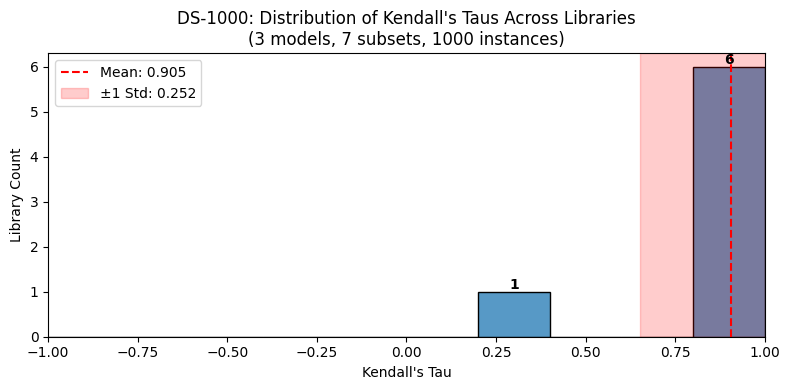

In [81]:
column = "kendall_tau"
xlabel = "Kendall's Tau"
ylabel = f"{subset_col.capitalize()} Count"
title = (
    f"{dataset}: Distribution of Kendall's Taus Across Libraries"
    f"\n({num_models} models, {len(subsets)} subsets, {num_instances} instances)"
)
annotate = True
mean = kendall_tau_df[column].mean()
std = kendall_tau_df[column].std()
xlim = (-1, 1)

fig = plot_histogram(
    kendall_tau_df,
    column=column,
    xlabel=xlabel,
    ylabel=ylabel,
    title=title,
    annotate=annotate,
    mean=mean,
    std=std,
    xlim=xlim,
)

analysis = "inter_subset_analysis"
plot_name = f"kendall_tau_distribution_{subset_col}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

### Performance Analysis

Compute each model's mean performance across the entire dataset.

In [82]:
mean_accuracy_df = (
    model_scores_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)
mean_accuracy_df.round(3).head()

,model,accuracy
2,gpt-4o-2024-08-06,0.598
1,gpt-3.5-turbo-0613,0.387
0,deepseek-coder-6.7b-base,0.312


Compute each model's mean performance on each subset.

In [83]:
kwargs = {
    "desc": "Computing mean performance",
    "total": len(subsets),
    "unit": "subset",
}

accuracy_results = {}

for subset in tqdm(subsets, **kwargs):
    mask = get_metadata_mask(dataset_df, subset_col, subset)
    subset_model_scores = model_scores_df[mask]
    accuracy_results[subset] = subset_model_scores.mean()

accuracy_df = pd.DataFrame(accuracy_results).T
accuracy_df.index.name = "subset"
accuracy_df.head()

Computing mean performance: 100%|██████████| 7/7 [00:00<00:00, 1704.61subset/s]

,deepseek-coder-6.7b-base,gpt-3.5-turbo-0613,gpt-4o-2024-08-06
subset,,,
Matplotlib,0.522581,0.593548,0.754839
Tensorflow,0.222222,0.333333,0.488889
Sklearn,0.382609,0.356522,0.513043
Scipy,0.245283,0.396226,0.613208
Pytorch,0.191176,0.294118,0.676471


Plot the distribution of each model's mean performance across the different subsets.

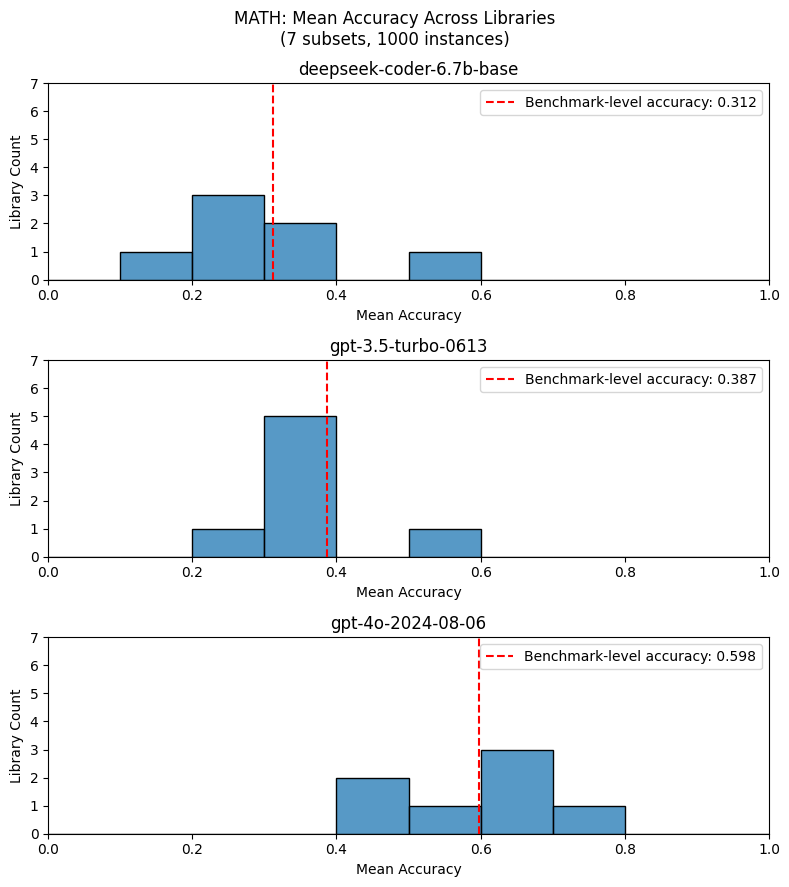

In [ ]:
global_means = model_scores_df.mean()
fig, axes = plt.subplots(num_models, 1, figsize=(8, 3 * num_models))

for i, model in enumerate(accuracy_df.columns):
    column = model
    xlabel = "Mean Accuracy"
    ylabel = f"{subset_col.capitalize()} Count"
    title = f"{model}"
    ax = axes[i] if num_models > 1 else axes
    mean = global_means[model]
    mean_label = "Benchmark-level accuracy"
    xlim = (0, 1)
    ylim = (0, num_subsets)

    plot_histogram(
        accuracy_df,
        column=column,
        xlabel=xlabel,
        ylabel=ylabel,
        title=title,
        ax=ax,
        mean=mean,
        mean_label=mean_label,
        xlim=xlim,
        ylim=ylim,
    )

plt.suptitle(
    f"{dataset}: Mean Accuracy Across Libraries"
    f"\n({len(subsets)} subsets, {num_instances} instances)"
)
plt.tight_layout()
plot_name = f"accuracy_distribution_{subset_col}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

## MATH

Load the raw dataset and evaluation results.

In [85]:
dataset = Dataset.MATH
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
eval_results_df = eval_results_df.drop(columns=["gpt-4o-mini-2024-07-18"])
models = eval_results_df.columns.tolist()

num_instances, num_models = len(dataset_df), len(models)

print(f"Number of instances: {num_instances}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {num_models}")
display(eval_results_df.head())

NameError: name 'resolve_dataset_path' is not defined

### Ranking Analysis

Compute the global model ranking.

In [ ]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

Count the number of subsets where the local model ranking differs from the global model ranking.

In [ ]:
subset_col = "subset"
subsets = dataset_df[subset_col].unique().tolist()
print(f"Subsets: {subsets}")

num_different = 0

for subset in subsets:
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from the global ranking: {num_different}")

Compute the Kendall's Tau between each subset's model ranking and the global model ranking. 

In [ ]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

kendall_tau_results = []

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    kendall_tau_results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": mask.sum(),
        }
    )

kendall_tau_df = pd.DataFrame(kendall_tau_results)
kendall_tau_df.head()

Plot the distribution of Kendall's Taus between each subset's model ranking and the global model ranking.

In [ ]:
# Compute mean and std
mean_tau = kendall_tau_df["kendall_tau"].mean()
std_tau = kendall_tau_df["kendall_tau"].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=kendall_tau_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel(f"{subset_col.capitalize()} Count")

without_gpt_4o_mini = "gpt-4o-mini-2024-07-18" not in models
note = " (without gpt-4o-mini-2024-07-18)" if without_gpt_4o_mini else ""
ax.set_title(
    f"{dataset}: Distribution of Kendall's Taus Across {subset_col.capitalize()}s{note}"
    f"\n({num_models} models, {len(subsets)} subsets, {num_instances} instances)"
)

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Add vertical line at mean
ax.axvline(
    mean_tau,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_tau:.3g}",
)

# Add shaded region for +/- 1 std
ax.axvspan(
    mean_tau - std_tau,
    mean_tau + std_tau,
    alpha=0.2,
    color="red",
    label=f"±1 Std: {std_tau:.3g}",
)

ax.legend()
plt.tight_layout()

suffix = "_without_gpt-4o-mini-2024-07-18" if without_gpt_4o_mini else ""
plot_name = f"kendall_tau_distribution{suffix}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

### Performance Analysis

Compute each model's mean performance across the entire dataset.

In [ ]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)
mean_accuracy_df.round(3).head()

Compute each model's mean performance on each subset.

In [ ]:
kwargs = {
    "desc": "Computing mean performance",
    "total": len(subsets),
    "unit": "subset",
}

accuracy_results = {}

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    accuracy_results[subset] = subset_eval_results_df.mean()

accuracy_df = pd.DataFrame(accuracy_results).T
accuracy_df.index.name = "subset"
accuracy_df.head()

Plot the distribution of each model's mean performance across the different subsets.

In [ ]:
global_means = eval_results_df.mean()
fig, axes = plt.subplots(num_models, 1, figsize=(8, 3 * num_models))

for i, model in enumerate(accuracy_df.columns):
    ax = axes[i] if num_models > 1 else axes
    sns.histplot(data=accuracy_df, x=model, ax=ax, bins=10)
    ax.set_xlabel("Mean Accuracy")
    ax.set_ylabel(f"{subset_col.capitalize()} Count")
    ax.set_title(f"{model}")
    ax.set_xlim(0, 1)

    # Add vertical line for global mean
    global_mean = global_means[model]
    ax.axvline(
        global_mean,
        color="red",
        linestyle="--",
        label=f"Benchmark-level accuracy: {global_mean:.3f}",
    )
    ax.legend()

plt.suptitle(
    f"{dataset}: Mean Accuracy Across {subset_col.capitalize()}s"
    f"\n({len(subsets)} subsets, {num_instances} instances)"
)
plt.tight_layout()
plot_name = f"accuracy_distribution_{subset_col}"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

## MMLU

Load the raw dataset and evaluation results.

In [ ]:
dataset = Dataset.MMLU
dataset_df = pd.read_json(resolve_dataset_path(dataset))
eval_results_df = load_eval_results(dataset)
models = eval_results_df.columns.tolist()

num_instances, num_models = len(dataset_df), len(models)

print(f"Number of instances: {num_instances}")
display(dataset_df.head())
print("-" * 200)
print(f"Number of models: {num_models}")
display(eval_results_df.head())

### Ranking Analysis

Compute the global model ranking.

In [ ]:
global_ranking = compute_ranking(eval_results_df)

for model, ranking in zip(models, global_ranking):
    print(f"{model}: {ranking}")

Count the number of subsets where the local model ranking differs from the global model ranking.

In [ ]:
subset_col = "subject"
subsets = dataset_df[subset_col].unique().tolist()
print(f"Subsets: {subsets}")

num_different = 0

for subset in subsets:
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    num_different += 1 if not np.array_equal(subset_ranking, global_ranking) else 0

print(f"Total number of subsets: {len(subsets)}")
print(f"Subsets that differ from the global ranking: {num_different}")

Compute the Kendall's Tau between each subset's model ranking and the global model ranking. 

In [ ]:
kwargs = {
    "desc": "Computing model rankings",
    "total": len(subsets),
    "unit": "subset",
}

kendall_tau_results = []

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    subset_ranking = compute_ranking(subset_eval_results_df)
    kendall_tau, _ = kendalltau(global_ranking, subset_ranking)
    kendall_tau_results.append(
        {
            "subset": subset,
            "ranking": subset_ranking,
            "kendall_tau": kendall_tau,
            "n_instances": mask.sum(),
        }
    )

kendall_tau_df = pd.DataFrame(kendall_tau_results)
kendall_tau_df.head()

Plot the distribution of Kendall's Taus between each subset's model ranking and the full dataset's model ranking.

In [ ]:
# Compute mean and std
mean_tau = kendall_tau_df["kendall_tau"].mean()
std_tau = kendall_tau_df["kendall_tau"].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=kendall_tau_df, x="kendall_tau", ax=ax)
ax.set_xlabel("Kendall's Tau")
ax.set_ylabel(f"{subset_col.capitalize()} Count")
ax.set_title(
    f"{dataset}: Distribution of Kendall's Taus Across {subset_col.capitalize()}s"
    f"\n({num_models} models, {len(subsets)} subsets, {num_instances} instances)"
)

for bar in ax.patches:
    if (height := bar.get_height()) == 0:
        continue
    ax.annotate(
        f"{int(height)}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Add vertical line at mean
ax.axvline(
    mean_tau,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_tau:.3g}",
)

# Add shaded region for +/- 1 std
ax.axvspan(
    mean_tau - std_tau,
    mean_tau + std_tau,
    alpha=0.2,
    color="red",
    label=f"±1 Std: {std_tau:.3g}",
)

ax.legend()
plt.tight_layout()
plot_name = "kendall_tau_distribution"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()

### Performance Analysis

Compute each model's mean performance across the entire dataset.

In [ ]:
mean_accuracy_df = (
    eval_results_df.mean(axis=0)
    .reset_index(name="accuracy")
    .rename(columns={"index": "model"})
)
mean_accuracy_df.sort_values(by="accuracy", ascending=False, inplace=True)
mean_accuracy_df.round(3).head()

Compute each model's mean performance on each subset.

In [ ]:
kwargs = {
    "desc": "Computing mean performance",
    "total": len(subsets),
    "unit": "subset",
}

accuracy_results = {}

for subset in tqdm(subsets, **kwargs):
    mask = dataset_df[subset_col] == subset
    subset_eval_results_df = eval_results_df[mask]
    accuracy_results[subset] = subset_eval_results_df.mean()

accuracy_df = pd.DataFrame(accuracy_results).T
accuracy_df.index.name = "subset"
accuracy_df.head()

Plot the distribution of each model's performance across the different subsets.

In [ ]:
global_means = eval_results_df.mean()
fig, axes = plt.subplots(num_models, 1, figsize=(8, 3 * num_models))

for i, model in enumerate(accuracy_df.columns):
    ax = axes[i] if num_models > 1 else axes
    sns.histplot(data=accuracy_df, x=model, ax=ax, bins=10)
    ax.set_xlabel("Mean Accuracy")
    ax.set_ylabel(f"{subset_col.capitalize()} Count")
    ax.set_title(f"{model}")
    ax.set_xlim(0, 1)

    # Add vertical line for global mean
    global_mean = global_means[model]
    ax.axvline(
        global_mean,
        color="red",
        linestyle="--",
        label=f"Benchmark-level accuracy: {global_mean:.3f}",
    )
    ax.legend()

plt.suptitle(
    f"{dataset}: Mean Accuracy Across {subset_col.capitalize()}s"
    f"\n({len(subsets)} subsets, {num_instances} instances)",
    y=1.01,
)
plt.tight_layout()
plot_name = "accuracy_distribution"
file_path = build_plot_path(dataset, analysis, plot_name)
plt.savefig(file_path)
plt.show()